<a href="https://colab.research.google.com/github/Gabrieltkessler/DI_Bootcamp/blob/main/Pokemon_Win_Prediction_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install pandas --quiet
!pip install numpy --quiet
!pip install scipy --quiet
!pip install matplotlib --quiet
!pip install seaborn --quiet

In [37]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [10]:
from google.colab import files
files.upload()

Saving combats.csv to combats.csv
Saving pokemon.csv to pokemon.csv
Saving tests.csv to tests.csv


{'combats.csv': b'First_pokemon,Second_pokemon,Winner\n266,298,298\n702,701,701\n191,668,668\n237,683,683\n151,231,151\n657,752,657\n192,134,134\n73,545,545\n220,763,763\n302,31,31\n442,130,130\n701,624,701\n15,283,283\n151,87,151\n269,462,269\n763,448,448\n143,263,263\n365,240,240\n499,774,499\n563,578,563\n440,687,687\n373,441,441\n654,671,671\n121,355,121\n609,649,649\n270,708,270\n460,568,568\n626,767,767\n139,451,139\n694,747,694\n455,549,549\n181,301,301\n208,184,184\n536,365,536\n260,381,381\n471,269,269\n621,287,287\n406,134,406\n592,503,503\n564,242,242\n579,242,242\n200,719,200\n376,135,376\n76,441,441\n667,645,645\n475,400,475\n3,737,737\n435,45,435\n231,146,146\n510,715,715\n456,260,260\n164,751,751\n424,754,424\n258,779,258\n360,208,208\n723,646,646\n384,533,533\n734,673,673\n141,721,141\n244,741,244\n509,217,509\n633,44,633\n595,719,595\n606,40,606\n368,598,368\n746,584,746\n350,187,350\n303,198,303\n169,701,701\n569,115,115\n231,172,172\n71,440,71\n659,610,610\n570,557,5

In [11]:
df1 = pd.read_csv('pokemon.csv')
df2 = pd.read_csv('combats.csv')
merged_df = pd.merge(df2, df1, left_on='First_pokemon', right_on='#', how='left')


In [12]:
merged_df.head()

,First_pokemon,Second_pokemon,Winner,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,266,298,298,266,Larvitar,Rock,Ground,50,64,50,45,50,41,2,False
1,702,701,701,702,Virizion,Grass,Fighting,91,90,72,90,129,108,5,True
2,191,668,668,191,Togetic,Fairy,Flying,55,40,85,80,105,40,2,False
3,237,683,683,237,Slugma,Fire,NaN,40,40,40,70,40,20,2,False
4,151,231,151,151,Omastar,Rock,Water,70,60,125,115,70,55,1,False


In [13]:
df = merged_df

In [14]:
df['Type 2'] = df['Type 2'].fillna('None')
df.loc[(df['#'] == 62) & (df['Name'].isna()), 'Name'] = 'Primeape'

In [15]:
df[df['Name'].isnull()]
df.loc[df['#'] == 62, 'Name'] = 'Primeape'
df['Name'] = df['Name'].fillna('Unknown')

In [16]:
df.head()

,First_pokemon,Second_pokemon,Winner,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,266,298,298,266,Larvitar,Rock,Ground,50,64,50,45,50,41,2,False
1,702,701,701,702,Virizion,Grass,Fighting,91,90,72,90,129,108,5,True
2,191,668,668,191,Togetic,Fairy,Flying,55,40,85,80,105,40,2,False
3,237,683,683,237,Slugma,Fire,None,40,40,40,70,40,20,2,False
4,151,231,151,151,Omastar,Rock,Water,70,60,125,115,70,55,1,False


In [17]:
battles = pd.concat([
    df['First_pokemon'],
    df['Second_pokemon']
]).value_counts()

wins = df['Winner'].value_counts()

win_stats = pd.DataFrame({
    'Battles': battles,
    'Wins': wins
}).fillna(0)

win_stats['Win_Percentage'] = (
    win_stats['Wins'] / win_stats['Battles']
) * 100

In [19]:
win_stats.head()

,Battles,Wins,Win_Percentage
1,133,37.0,27.819549
2,121,46.0,38.016529
3,132,89.0,67.424242
4,125,70.0,56.000000
5,112,55.0,49.107143


In [20]:
df.columns

Index(['First_pokemon', 'Second_pokemon', 'Winner', '#', 'Name', 'Type 1',
       'Type 2', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed',
       'Generation', 'Legendary'],
      dtype='object')

In [25]:
pokemon_with_win_stats = pd.merge(df1, win_stats, left_on='#', right_index=True, how='left')
display(pokemon_with_win_stats.head())

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Battles,Wins,Win_Percentage
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,133.0,37.0,27.819549
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,121.0,46.0,38.016529
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,132.0,89.0,67.424242
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,125.0,70.0,56.000000
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False,112.0,55.0,49.107143


In [26]:
selected_columns = ['HP', 'Attack', 'Speed', 'Win_Percentage']
correlation_matrix = pokemon_with_win_stats[selected_columns].corr()
display(correlation_matrix)

,HP,Attack,Speed,Win_Percentage
HP,1.000000,0.422386,0.175952,0.261602
Attack,0.422386,1.000000,0.381240,0.502825
Speed,0.175952,0.381240,1.000000,0.938055
Win_Percentage,0.261602,0.502825,0.938055,1.000000


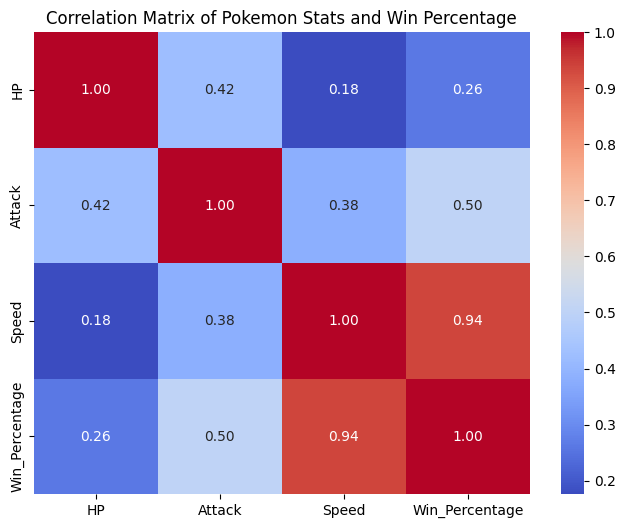

In [27]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Pokemon Stats and Win Percentage')
plt.show()

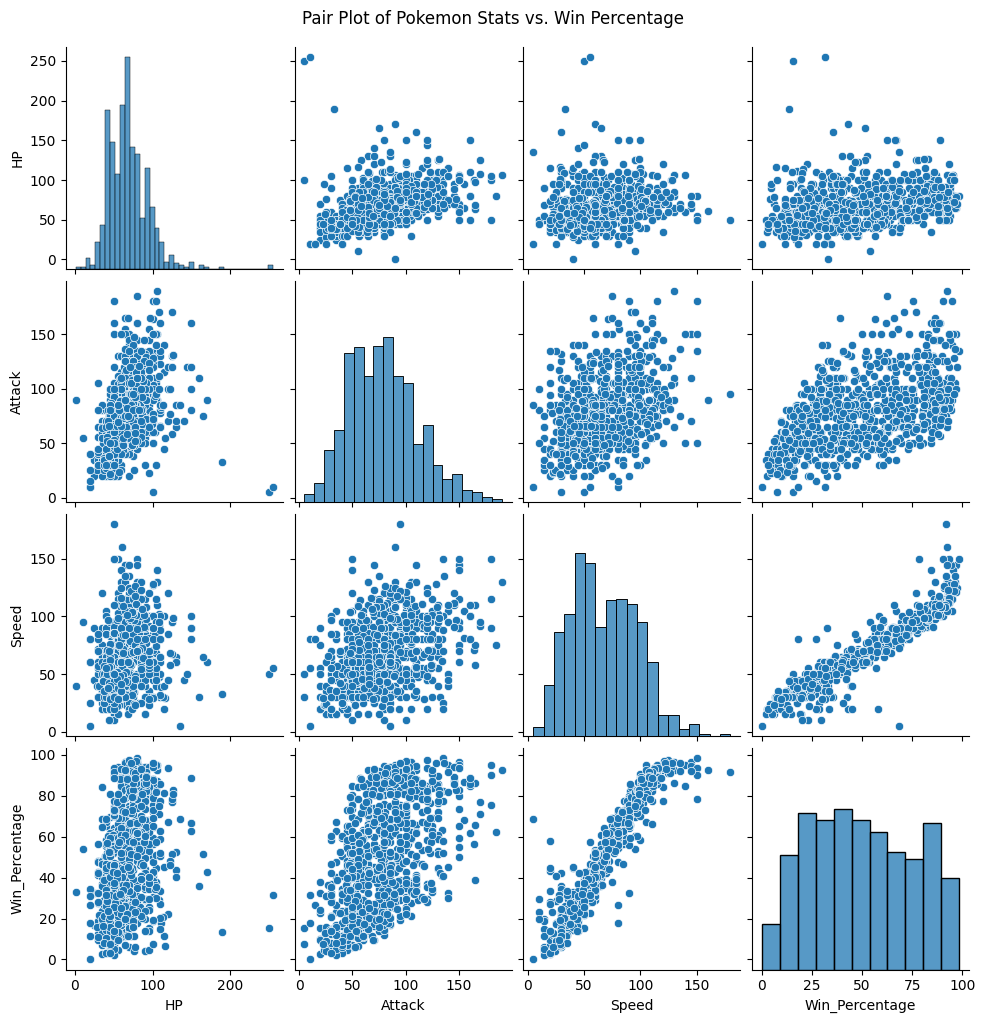

In [29]:
sns.pairplot(pokemon_with_win_stats[selected_columns])
plt.suptitle('Pair Plot of Pokemon Stats vs. Win Percentage', y=1.02)
plt.show()

In [31]:
pokemon_with_win_stats.head(10)['Name']

,Name
0,Bulbasaur
1,Ivysaur
2,Venusaur
3,Mega Venusaur
4,Charmander
5,Charmeleon
6,Charizard
7,Mega Charizard X
8,Mega Charizard Y
9,Squirtle


## Split Data into Training and Testing Sets

In [40]:
# Fill any NaN values in 'Win_Percentage' with 0 before defining features and target
pokemon_with_win_stats['Win_Percentage'] = pokemon_with_win_stats['Win_Percentage'].fillna(0)

# Define features (X) and target (y)
X = pokemon_with_win_stats[['HP', 'Attack', 'Speed']]
y = pokemon_with_win_stats['Win_Percentage']

# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (640, 3)
X_test shape: (160, 3)
y_train shape: (640,)
y_test shape: (160,)


## Model Training and Evaluation

### 1. Linear Regression

In [41]:
# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test)

# Evaluate the model
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression - Mean Squared Error: {mse_linear:.2f}")
print(f"Linear Regression - R-squared: {r2_linear:.2f}")

Linear Regression - Mean Squared Error: 111.57
Linear Regression - R-squared: 0.83


### 2. XGBoost Regressor

In [42]:
# Initialize and train the XGBoost Regressor model
xgboost_model = XGBRegressor(random_state=42)
xgboost_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgboost = xgboost_model.predict(X_test)

# Evaluate the model
mse_xgboost = mean_squared_error(y_test, y_pred_xgboost)
r2_xgboost = r2_score(y_test, y_pred_xgboost)

print(f"XGBoost Regressor - Mean Squared Error: {mse_xgboost:.2f}")
print(f"XGBoost Regressor - R-squared: {r2_xgboost:.2f}")

XGBoost Regressor - Mean Squared Error: 115.54
XGBoost Regressor - R-squared: 0.82


### 3. Random Forest Regressor

In [44]:
# Initialize and train the Random Forest Regressor model
random_forest_model = RandomForestRegressor(random_state=42)
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_forest = random_forest_model.predict(X_test)

# Evaluate the model
mse_forest = mean_squared_error(y_test, y_pred_forest)
r2_forest = r2_score(y_test, y_pred_forest)

print(f"Random Forest Regressor - Mean Squared Error: {mse_forest:.2f}")
print(f"Random Forest Regressor - R-squared: {r2_forest:.2f}")

Random Forest Regressor - Mean Squared Error: 96.97
Random Forest Regressor - R-squared: 0.85


## Model Comparison using Mean Absolute Error (MAE)

In [45]:
from sklearn.metrics import mean_absolute_error

# Calculate MAE for Linear Regression
mae_linear = mean_absolute_error(y_test, y_pred_linear)
print(f"Linear Regression - Mean Absolute Error: {mae_linear:.2f}")

# Calculate MAE for XGBoost Regressor
mae_xgboost = mean_absolute_error(y_test, y_pred_xgboost)
print(f"XGBoost Regressor - Mean Absolute Error: {mae_xgboost:.2f}")

# Calculate MAE for Random Forest Regressor
mae_forest = mean_absolute_error(y_test, y_pred_forest)
print(f"Random Forest Regressor - Mean Absolute Error: {mae_forest:.2f}")

Linear Regression - Mean Absolute Error: 6.60
XGBoost Regressor - Mean Absolute Error: 6.52
Random Forest Regressor - Mean Absolute Error: 5.77
